## 1. Preparação

Importação das bibliotecas e configuração do ambiente.

Utilizamos apenas bibliotecas de **leitura, tratamento de dados e visualização** —
nenhuma biblioteca que contenha o algoritmo KNN implementado é importada nesta etapa.
O `Scikit-learn` só será importado na **Célula 6**, exclusivamente para a comparação
com a implementação *hardcore*.

- `numpy` → estruturas de dados e operações matemáticas (distâncias, votação)
- `pandas` → leitura e tratamento do CSV
- `matplotlib` → visualização (matriz de confusão)
- `random` → embaralhamento dos dados no split (sem depender de bibliotecas de ML)

A *seed* é fixada para garantir a **reprodutibilidade** dos experimentos.

In [36]:
import numpy as np              
import pandas as pd             
import matplotlib.pyplot as plt 
import seaborn as sns           
import random                   

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (6, 5)

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


## 2. Tratamento dos dados

Nesta etapa a base **Iris** é carregada a partir do arquivo CSV e separada em
conjuntos de **treino (70%)** e **teste (30%)**.

### Leitura e limpeza

O arquivo é lido com `pandas`. Caso exista a coluna `Id` (presente na versão do
Kaggle), ela é removida por ser apenas um identificador, sem valor preditivo.
Em seguida os dados são divididos em:

- `X` → a matriz de **atributos** (features): comprimento e largura da sépala e
  da pétala;
- `y` → o vetor de **classes** (a coluna `Species`).

Ambos são convertidos para arrays do `numpy`, o que facilita as operações
matemáticas nas etapas seguintes.

### Separação treino/teste (split 70/30)

O split é feito **manualmente**, sem utilizar bibliotecas de machine learning:

1. Cria-se uma lista com os índices de todas as amostras;
2. Essa lista é **embaralhada** aleatoriamente (usando a *seed* fixada na Célula 1,
   garantindo reprodutibilidade);
3. Os primeiros 30% dos índices formam o conjunto de **teste** e os 70% restantes
   o de **treino**.

O embaralhamento é importante porque a base Iris vem **ordenada por classe** — sem
ele, o conjunto de teste conteria apenas amostras das últimas classes, invalidando
a avaliação.

> **Configuração:** as variáveis `CAMINHO_CSV`, `COLUNA_CLASSE` e `PROP_TESTE`
> ficam no topo da célula para facilitar a reutilização do notebook com **outras
> bases de dados**.

In [37]:
CAMINHO_CSV = "Iris.csv"
COLUNA_CLASSE = "Species"
PROP_TESTE = 0.30

df = pd.read_csv(CAMINHO_CSV)

if "Id" in df.columns:
    df = df.drop(columns=["Id"])

X = df.drop(columns=[COLUNA_CLASSE]).to_numpy(dtype=float)
y = df[COLUNA_CLASSE].to_numpy()

indices = list(range(len(df)))
random.shuffle(indices)

n_teste = int(len(df) * PROP_TESTE)
indices_teste = indices[:n_teste]
indices_treino = indices[n_teste:]

X_treino, y_treino = X[indices_treino], y[indices_treino]
X_teste, y_teste = X[indices_teste], y[indices_teste]

print(f"Total de amostras: {len(df)}")
print(f"Treino: {len(X_treino)} amostras ({len(X_treino)/len(df):.0%})")
print(f"Teste:  {len(X_teste)} amostras ({len(X_teste)/len(df):.0%})")
print(f"Atributos (features): {X.shape[1]}")
print(f"Classes: {sorted(set(y))}")

Total de amostras: 150
Treino: 105 amostras (70%)
Teste:  45 amostras (30%)
Atributos (features): 4
Classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


## 3. Treino

Aqui definimos o classificador **KNN implementado do zero**, encapsulado em uma
classe (`KNNClassifier`) para manter o código organizado e reutilizável.

### Por que o "treino" do KNN é apenas armazenar os dados

O KNN é um algoritmo de **aprendizado preguiçoso** (*lazy learning*): ele **não
constrói um modelo** nem ajusta parâmetros durante o treino. A etapa de treino
(`fit`) consiste unicamente em **memorizar** o conjunto de treino. Todo o esforço
computacional é adiado para o momento da predição, quando as distâncias são
calculadas.

### Componentes da implementação

- **`fit(X, y)`** — armazena os dados de treino (a "fase de treino").
- **`_distancia(a, b)`** — calcula a **distância euclidiana** entre duas amostras:

  $$d(a, b) = \sqrt{\sum_{i=1}^{n}(a_i - b_i)^2}$$

- **`_prever_um(amostra)`** — para uma única amostra:
  1. calcula a distância dela até **todas** as amostras de treino;
  2. seleciona os índices dos **`k` vizinhos mais próximos** (menores distâncias);
  3. aplica **votação majoritária** — a classe mais frequente entre os vizinhos
     é a previsão (`Counter.most_common`).

- **`predict(X)`** — aplica `_prever_um` a cada amostra de um conjunto, retornando
  um array de previsões.

O parâmetro **`k`** (número de vizinhos) é definido na criação do objeto. Nesta
célula usamos `k = 3` como exemplo; na Célula 5 o classificador será avaliado para
`k = {1, 3, 5, 7}`.

In [38]:
from collections import Counter


class KNNClassifier:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_treino = np.asarray(X, dtype=float)
        self.y_treino = np.asarray(y)
        return self

    def _distancia(self, a, b):
        return np.sqrt(np.sum((a - b) ** 2))

    def _prever_um(self, amostra):
        distancias = [self._distancia(amostra, treino) for treino in self.X_treino]
        vizinhos = np.argsort(distancias)[:self.k]
        classes_vizinhas = self.y_treino[vizinhos]
        return Counter(classes_vizinhas).most_common(1)[0][0]

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.array([self._prever_um(amostra) for amostra in X])


modelo = KNNClassifier(k=3)
modelo.fit(X_treino, y_treino)

print("Classificador KNN definido e dados de treino armazenados.")
print(f"k = {modelo.k}")
print(f"Amostras de treino armazenadas: {len(modelo.X_treino)}")

Classificador KNN definido e dados de treino armazenados.
k = 3
Amostras de treino armazenadas: 105


## 4. Predição pontual

Antes de avaliar o classificador sobre todo o conjunto de teste, fazemos uma
**verificação individual**: uma amostra é escolhida **aleatoriamente** do conjunto
de teste, classificada pelo modelo e comparada com o seu rótulo verdadeiro.

Essa etapa é apenas ilustrativa — serve para demonstrar, de forma transparente,
como o KNN atua sobre um único ponto:

1. Uma amostra de teste é sorteada;
2. Seus atributos são exibidos;
3. O método `_prever_um` calcula a classe prevista com base nos `k` vizinhos mais
   próximos do conjunto de treino;
4. A previsão é comparada com a **classe real**, indicando acerto ou erro.

Como a amostra é sorteada aleatoriamente (respeitando a *seed*), cada execução
completa do notebook analisa um ponto específico e reprodutível.

In [39]:
i = random.randrange(len(X_teste))

amostra = X_teste[i]
classe_real = y_teste[i]
classe_prevista = modelo._prever_um(amostra)

print(f"Amostra de teste selecionada (índice {i}):")
print(f"  Atributos: {amostra}")
print(f"  Classe real:     {classe_real}")
print(f"  Classe prevista: {classe_prevista}")
print(f"  Resultado: {'ACERTOU' if classe_prevista == classe_real else 'ERROU'}")

Amostra de teste selecionada (índice 16):
  Atributos: [7.9 3.8 6.4 2. ]
  Classe real:     Iris-virginica
  Classe prevista: Iris-virginica
  Resultado: ACERTOU


## 5. Resultados e acurácia

Nesta etapa o classificador é avaliado sobre **todo o conjunto de teste**, para os
valores de **`k = {1, 3, 5, 7}`** exigidos pelo enunciado. Todas as métricas são
**implementadas do zero**, sem uso de bibliotecas de machine learning.

### Taxa de reconhecimento

A **taxa de reconhecimento** (acurácia) é a proporção de amostras de teste
classificadas corretamente. É calculada para cada valor de `k`.

### Matriz de confusão

A matriz de confusão é construída manualmente (`matriz_confusao`): cada linha
representa a **classe real** e cada coluna a **classe prevista**. A diagonal
principal contém os acertos; valores fora dela indicam os erros e entre quais
classes ocorreram.

### Métricas de avaliação

A partir da matriz de confusão (`calcular_metricas`), para cada classe:

- **Precisão** = VP / (VP + FP) → dos que foram previstos como a classe, quantos
  realmente eram. Corresponde a `verdadeiros_positivos / soma_da_coluna`.
- **Revocação** = VP / (VP + FN) → da classe real, quantos foram recuperados.
  Corresponde a `verdadeiros_positivos / soma_da_linha`.
- **Acurácia** = soma da diagonal / total de amostras.

Como o problema tem **três classes**, precisão e revocação são calculadas por
classe e apresentadas também como **média** (macro-average), fornecendo um valor
único que resume o desempenho do classificador.

Taxa de reconhecimento (acurácia) por valor de k:
  k = 1:  0.9333  (93.33%)
  k = 3:  0.9778  (97.78%)
  k = 5:  0.9778  (97.78%)
  k = 7:  0.9778  (97.78%)

===== k = 1 =====
Acurácia:          0.9333
Precisão (média):  0.9444
Revocação (média): 0.9408
  Iris-setosa        precisão=1.0000  revocação=1.0000
  Iris-versicolor    precisão=0.9333  revocação=0.8750
  Iris-virginica     precisão=0.9000  revocação=0.9474


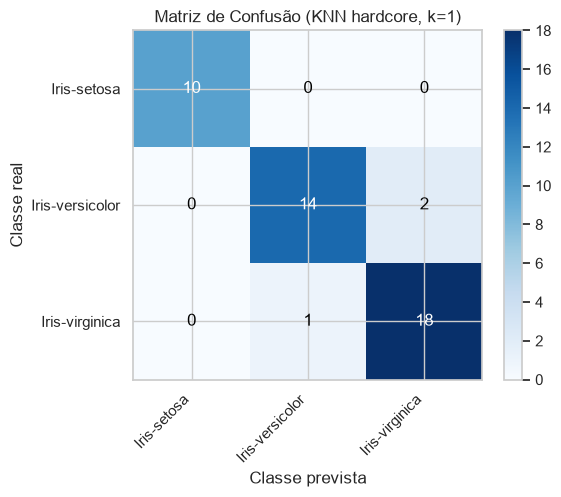


===== k = 3 =====
Acurácia:          0.9778
Precisão (média):  0.9833
Revocação (média): 0.9792
  Iris-setosa        precisão=1.0000  revocação=1.0000
  Iris-versicolor    precisão=1.0000  revocação=0.9375
  Iris-virginica     precisão=0.9500  revocação=1.0000


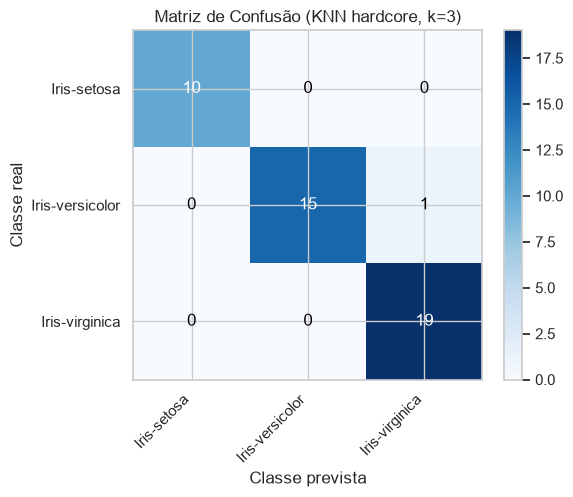


===== k = 5 =====
Acurácia:          0.9778
Precisão (média):  0.9833
Revocação (média): 0.9792
  Iris-setosa        precisão=1.0000  revocação=1.0000
  Iris-versicolor    precisão=1.0000  revocação=0.9375
  Iris-virginica     precisão=0.9500  revocação=1.0000


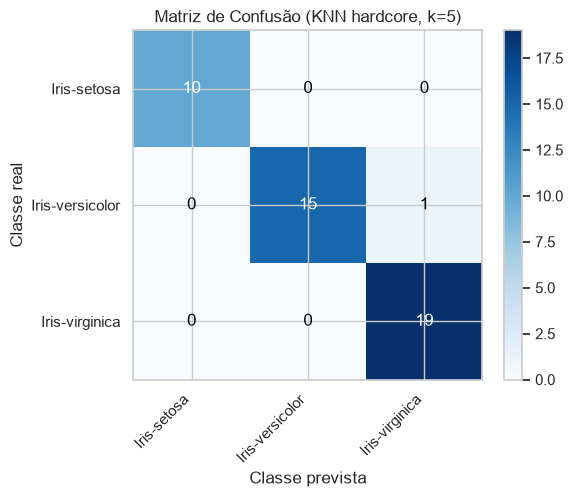


===== k = 7 =====
Acurácia:          0.9778
Precisão (média):  0.9833
Revocação (média): 0.9792
  Iris-setosa        precisão=1.0000  revocação=1.0000
  Iris-versicolor    precisão=1.0000  revocação=0.9375
  Iris-virginica     precisão=0.9500  revocação=1.0000


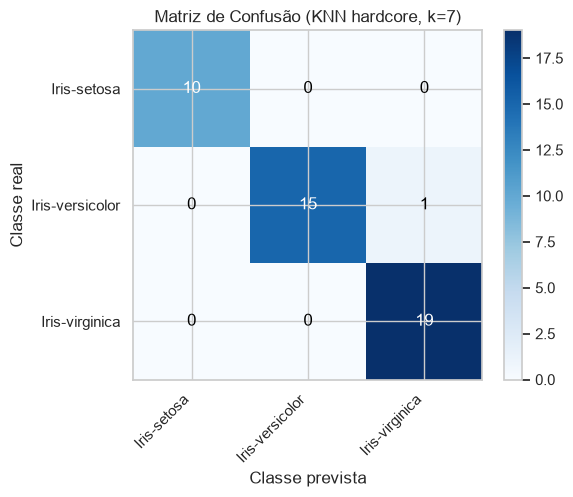

In [40]:
valores_k = [1, 3, 5, 7]
classes = sorted(set(y))


def matriz_confusao(y_real, y_prev, classes):
    idx = {c: i for i, c in enumerate(classes)}
    m = np.zeros((len(classes), len(classes)), dtype=int)
    for real, prev in zip(y_real, y_prev):
        m[idx[real]][idx[prev]] += 1
    return m


def calcular_metricas(m):
    total = m.sum()
    acuracia = np.trace(m) / total
    precisoes, revocacoes = [], []
    for i in range(len(m)):
        vp = m[i][i]
        soma_coluna = m[:, i].sum()
        soma_linha = m[i, :].sum()
        precisoes.append(vp / soma_coluna if soma_coluna > 0 else 0.0)
        revocacoes.append(vp / soma_linha if soma_linha > 0 else 0.0)
    return acuracia, np.mean(precisoes), np.mean(revocacoes), precisoes, revocacoes


def plotar_matriz(m, classes, titulo):
    fig, ax = plt.subplots()
    im = ax.imshow(m, cmap="Blues")
    ax.set_xticks(range(len(classes)))
    ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_yticklabels(classes)
    ax.set_xlabel("Classe prevista")
    ax.set_ylabel("Classe real")
    ax.set_title(titulo)
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, m[i][j], ha="center", va="center",
                    color="white" if m[i][j] > m.max() / 2 else "black")
    fig.colorbar(im)
    fig.tight_layout()
    plt.show()


print("Taxa de reconhecimento (acurácia) por valor de k:")
for k in valores_k:
    modelo_k = KNNClassifier(k=k).fit(X_treino, y_treino)
    y_prev = modelo_k.predict(X_teste)
    acc = np.mean(y_prev == y_teste)
    print(f"  k = {k}:  {acc:.4f}  ({acc:.2%})")

for k in valores_k:
    modelo_k = KNNClassifier(k=k).fit(X_treino, y_treino)
    y_prev = modelo_k.predict(X_teste)
    m = matriz_confusao(y_teste, y_prev, classes)
    acuracia, precisao, revocacao, prec_c, rev_c = calcular_metricas(m)

    print(f"\n===== k = {k} =====")
    print(f"Acurácia:          {acuracia:.4f}")
    print(f"Precisão (média):  {precisao:.4f}")
    print(f"Revocação (média): {revocacao:.4f}")
    for c, p, r in zip(classes, prec_c, rev_c):
        print(f"  {c:<18} precisão={p:.4f}  revocação={r:.4f}")

    plotar_matriz(m, classes, f"Matriz de Confusão (KNN hardcore, k={k})")

## 6. Comparação com o Scikit-learn

Nesta etapa final utilizamos o **`KNeighborsClassifier` do Scikit-learn** — a
implementação de terceiros — para os mesmos valores de `k`, e comparamos seus
resultados com a implementação *hardcore*.

Esta é a **única** célula que importa uma biblioteca com o algoritmo KNN pronto,
conforme permitido pelo enunciado para fins de comparação. As métricas do sklearn
são obtidas de `sklearn.metrics`.

### O que é comparado

- **Métricas de avaliação** (acurácia, precisão e revocação) das duas
  implementações, lado a lado, para cada valor de `k`. A coluna `dif` mostra a
  diferença absoluta entre elas.
- **Matriz de confusão** gerada pelo sklearn, para verificação visual.
- **Tempo de execução** (item opcional do enunciado): mede-se o tempo de `fit` +
  `predict` de cada implementação.

### O que se espera observar

Como ambas implementam o mesmo algoritmo (distância euclidiana + votação
majoritária), as **métricas devem ser idênticas** — a diferença esperada é zero.
Isso valida a correção da implementação *hardcore*.

A diferença relevante está no **desempenho computacional**: o sklearn tende a ser
significativamente mais rápido, pois é otimizado em baixo nível (C/Cython) e
emprega estruturas de dados espaciais (como *KD-Tree* / *Ball-Tree*) para acelerar
a busca de vizinhos, enquanto a versão *hardcore* calcula todas as distâncias de
forma direta em Python. Essa análise compõe a conclusão do relatório.

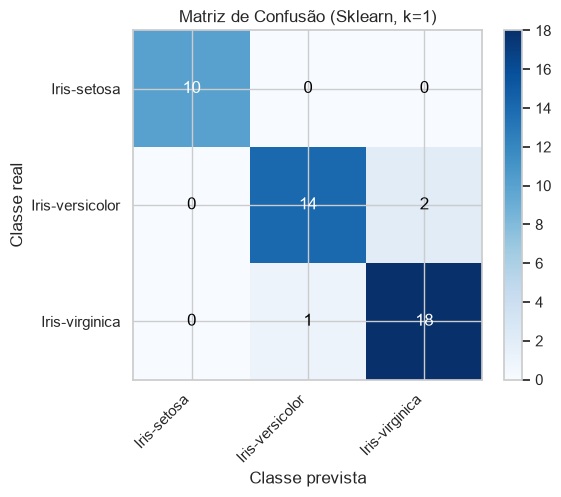

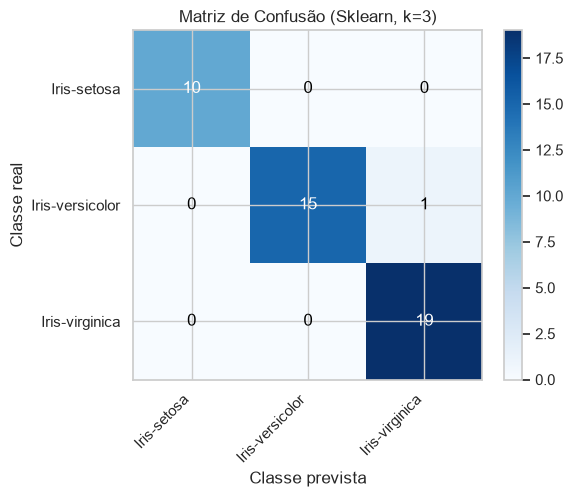

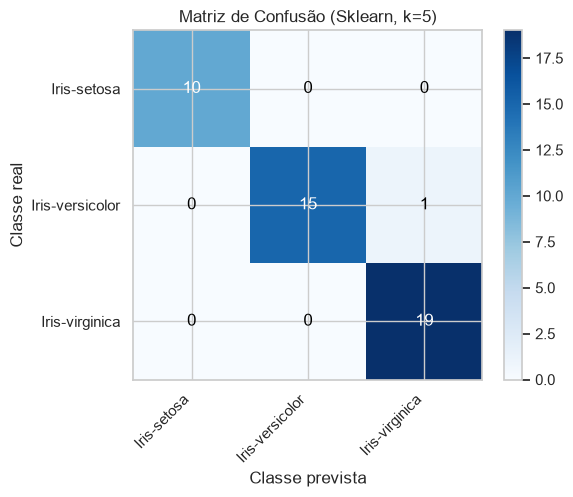

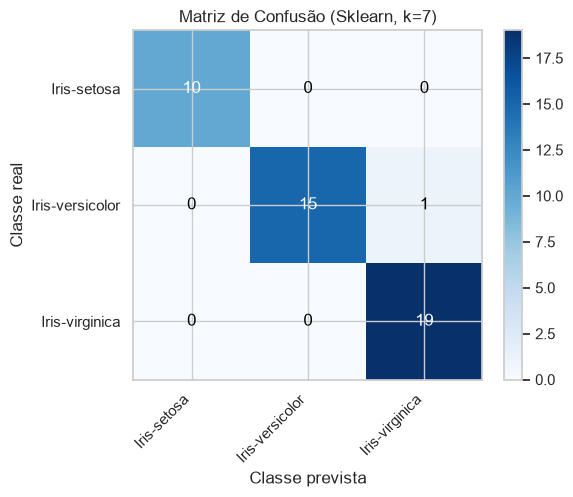

Comparação das métricas: hardcore x sklearn

  k | métrica    |  hardcore |   sklearn |     dif
----------------------------------------------------
  1 | acurácia   |    0.9333 |    0.9333 |  0.0000
  1 | precisão   |    0.9444 |    0.9444 |  0.0000
  1 | revocação  |    0.9408 |    0.9408 |  0.0000
----------------------------------------------------
  3 | acurácia   |    0.9778 |    0.9778 |  0.0000
  3 | precisão   |    0.9833 |    0.9833 |  0.0000
  3 | revocação  |    0.9792 |    0.9792 |  0.0000
----------------------------------------------------
  5 | acurácia   |    0.9778 |    0.9778 |  0.0000
  5 | precisão   |    0.9833 |    0.9833 |  0.0000
  5 | revocação  |    0.9792 |    0.9792 |  0.0000
----------------------------------------------------
  7 | acurácia   |    0.9778 |    0.9778 |  0.0000
  7 | precisão   |    0.9833 |    0.9833 |  0.0000
  7 | revocação  |    0.9792 |    0.9792 |  0.0000
----------------------------------------------------

Tempo de execução (fit + p

In [41]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import time


for k in valores_k:
    modelo_sk = KNeighborsClassifier(n_neighbors=k)
    modelo_sk.fit(X_treino, y_treino)
    y_prev_sk = modelo_sk.predict(X_teste)
    m_sk = confusion_matrix(y_teste, y_prev_sk, labels=classes)
    plotar_matriz(m_sk, classes, f"Matriz de Confusão (Sklearn, k={k})")


print("Comparação das métricas: hardcore x sklearn\n")
print(f"{'k':>3} | {'métrica':<10} | {'hardcore':>9} | {'sklearn':>9} | {'dif':>7}")
print("-" * 52)
for k in valores_k:
    hc = KNNClassifier(k=k).fit(X_treino, y_treino)
    yp_hc = hc.predict(X_teste)
    ac_hc, pr_hc, rv_hc = calcular_metricas(matriz_confusao(y_teste, yp_hc, classes))[:3]

    sk = KNeighborsClassifier(n_neighbors=k).fit(X_treino, y_treino)
    yp_sk = sk.predict(X_teste)
    ac_sk = accuracy_score(y_teste, yp_sk)
    pr_sk = precision_score(y_teste, yp_sk, average="macro", zero_division=0)
    rv_sk = recall_score(y_teste, yp_sk, average="macro", zero_division=0)

    for nome, vhc, vsk in [("acurácia", ac_hc, ac_sk),
                           ("precisão", pr_hc, pr_sk),
                           ("revocação", rv_hc, rv_sk)]:
        print(f"{k:>3} | {nome:<10} | {vhc:>9.4f} | {vsk:>9.4f} | {abs(vhc - vsk):>7.4f}")
    print("-" * 52)


print("\nTempo de execução (fit + predict), k = 3:")
inicio = time.perf_counter()
KNNClassifier(k=3).fit(X_treino, y_treino).predict(X_teste)
tempo_hc = time.perf_counter() - inicio

inicio = time.perf_counter()
KNeighborsClassifier(n_neighbors=3).fit(X_treino, y_treino).predict(X_teste)
tempo_sk = time.perf_counter() - inicio

print(f"  hardcore: {tempo_hc * 1000:.2f} ms")
print(f"  sklearn:  {tempo_sk * 1000:.2f} ms")